In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import sys
from pathlib import Path

# Ruta raíz del proyecto en Drive
PROJECT_PATH = Path("/content/drive/MyDrive/proyecto_AAIII_02_diffusion_models")

# Carpetas principales
NOTEBOOKS_DIR = PROJECT_PATH / "notebooks"
SRC_DIR = PROJECT_PATH / "src"
CHECKPOINTS_DIR = PROJECT_PATH / "checkpoints"
RESULTS_DIR = PROJECT_PATH / "results"

# Añadir src al path para poder importar los .py
sys.path.insert(0, str(SRC_DIR))

# Crear carpetas si no existen
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_PATH =", PROJECT_PATH)
print("SRC_DIR =", SRC_DIR)
print("CHECKPOINTS_DIR =", CHECKPOINTS_DIR)
print("RESULTS_DIR =", RESULTS_DIR)

PROJECT_PATH = /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models
SRC_DIR = /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/src
CHECKPOINTS_DIR = /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/checkpoints
RESULTS_DIR = /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/results


# Training an Ornstein–Uhlenbeck / VP diffusion model on MNIST

This auxiliary notebook is used to train score-based diffusion models on MNIST using the Ornstein–Uhlenbeck (variance preserving) forward process. Different noise schedules can be considered, such as linear, cosine, and constant schedules. The resulting checkpoints will later be reused in the main notebook for generation and comparison.

In [ ]:
import os
import sys
from functools import partial


import torch
from torch.optim import Adam
from torch.utils.data import DataLoader, Subset
from torchvision import datasets
from torchvision.transforms import ToTensor
from tqdm.notebook import trange

from score_model import ScoreNet
from diffusion_utilities import plot_image_grid, plot_image_evolution
from ou_utils import (
    linear_beta_schedule,
    linear_beta_integral,
    cosine_beta_schedule,
    cosine_beta_integral,
    constant_beta_schedule,
    constant_beta_integral,
    ou_sigma_t,
    build_ou_diffusion_process,
    sample_ou_euler_maruyama,
    sample_ou_predictor_corrector,
    sample_ou_probability_flow_ode
)

In [ ]:
# Reproducibility
_ = torch.manual_seed(123)

# Device
if torch.backends.mps.is_available():
    device = "mps"
elif hasattr(torch, "xpu") and torch.xpu.is_available():
    device = "xpu"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

print("Device:", device)



Device: cuda


In [ ]:
schedule_name = "cosine"  # "linear", "cosine" o "constant"


if schedule_name == "linear":
    beta_schedule = partial(linear_beta_schedule, beta_min=0.1, beta_max=20.0)
    beta_integral = partial(linear_beta_integral, beta_min=0.1, beta_max=20.0)

elif schedule_name == "cosine":
    beta_schedule = partial(cosine_beta_schedule, s=0.008)
    beta_integral = partial(cosine_beta_integral, s=0.008)

elif schedule_name == "constant":
    beta_schedule = partial(constant_beta_schedule, beta_const=5.0)
    beta_integral = partial(constant_beta_integral, beta_const=5.0)

else:
    raise ValueError(f"Unknown schedule_name: {schedule_name}")


checkpoint_path = CHECKPOINTS_DIR / f"ou_mnist_all_digits_{schedule_name}.pth"

print("Schedule:", schedule_name)
print("Checkpoint path:", checkpoint_path)




Schedule: cosine
Checkpoint path: /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/checkpoints/ou_mnist_all_digits_cosine.pth


In [ ]:
# Load MNIST
data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
)

# Use the full MNIST training set (all digits 0-9)
data_train = data
print("Training subset size:", len(data_train))

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 471kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.44MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.2MB/s]

Training subset size: 60000


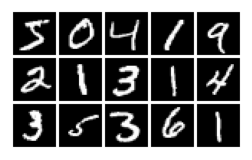

In [ ]:
n_rows = 3
n_cols = 5

_ = plot_image_grid(
    images=[data_train[i][0] for i in range(n_rows * n_cols)],
    figsize=(3, 3),
    n_rows=n_rows,
    n_cols=n_cols,
)

In [ ]:
batch_size = 64

data_loader = DataLoader(
    data_train,
    batch_size=batch_size,
    shuffle=True,
    num_workers=torch.get_num_threads(),
)

images_0 shape: torch.Size([64, 1, 28, 28])
images_t_vis shape: torch.Size([64, 1, 28, 28, 201])


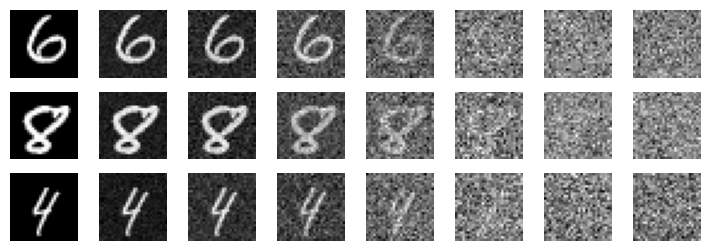

In [ ]:
# Forward diffusion with OU / VP process

import diffusion_process as dfp

# Take one mini-batch to illustrate the forward process
images_0, _ = next(iter(data_loader))
print("images_0 shape:", images_0.shape)

# OU forward SDE
def ou_drift_coefficient(x_t, t, beta_schedule):
    beta_t = beta_schedule(t).view(-1, 1, 1, 1)
    return -0.5 * beta_t * x_t

def ou_diffusion_coefficient(t, beta_schedule):
    return torch.sqrt(beta_schedule(t))

t_0 = 0.0
t_end = 1.0
n_steps_vis = 200

times_vis, images_t_vis = dfp.euler_maruyama_integrator(
    images_0,
    t_0,
    t_end,
    n_steps_vis,
    drift_coefficient=partial(ou_drift_coefficient, beta_schedule=beta_schedule),
    diffusion_coefficient=partial(ou_diffusion_coefficient, beta_schedule=beta_schedule),
)

print("images_t_vis shape:", images_t_vis.shape)

_ = plot_image_evolution(
    images=images_t_vis,
    n_images=3,
    n_intermediate_steps=[0, 5, 10, 20, 50, 100, 150, 199],
    figsize=(9, 3),
)

In [ ]:
diffusion_process = build_ou_diffusion_process(
    beta_schedule=beta_schedule,
    beta_integral=beta_integral,
)

In [ ]:
score_model = torch.nn.DataParallel(
    ScoreNet(
        marginal_prob_std=partial(ou_sigma_t, beta_integral=beta_integral)
    )
).to(device)

print(score_model)

DataParallel(
  (module): ScoreNet(
    (embed): Sequential(
      (0): GaussianRandomFourierFeatures()
      (1): Linear(in_features=256, out_features=256, bias=True)
    )
    (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (dense1): Dense(
      (dense): Linear(in_features=256, out_features=32, bias=True)
    )
    (gnorm1): GroupNorm(4, 32, eps=1e-05, affine=True)
    (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (dense2): Dense(
      (dense): Linear(in_features=256, out_features=64, bias=True)
    )
    (gnorm2): GroupNorm(32, 64, eps=1e-05, affine=True)
    (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (dense3): Dense(
      (dense): Linear(in_features=256, out_features=128, bias=True)
    )
    (gnorm3): GroupNorm(32, 128, eps=1e-05, affine=True)
    (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (dense4): Dense(
      (dense): Linear(in_features=256, out_features=

In [ ]:
checkpoint = torch.load(checkpoint_path, map_location=device)
score_model.load_state_dict(checkpoint)
score_model.eval()

print("Checkpoint loaded correctly from:", checkpoint_path)

Checkpoint loaded correctly from: /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/checkpoints/ou_mnist_all_digits_cosine.pth


In [ ]:
learning_rate = 1.0e-3
optimizer = Adam(score_model.parameters(), lr=learning_rate)

In [ ]:
n_epochs = 60
best_loss = float("inf")

tqdm_epoch = trange(n_epochs)

for epoch in tqdm_epoch:
    score_model.train()
    avg_loss = 0.0
    num_items = 0

    for x, _ in data_loader:
        x = x.to(device)

        loss = diffusion_process.loss_function(score_model, x)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        avg_loss += loss.item() * x.shape[0]
        num_items += x.shape[0]

    epoch_loss = avg_loss / num_items
    tqdm_epoch.set_description(f"Average Loss: {epoch_loss:8.5f}")

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(score_model.state_dict(), checkpoint_path)

  0%|          | 0/60 [00:00<?, ?it/s]

In [ ]:
score_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
score_model.eval()

print("Loaded checkpoint:", checkpoint_path)

Loaded checkpoint: /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/checkpoints/ou_mnist_all_digits_cosine.pth


In [ ]:
n_images = 25

times, synthetic_images_t = sample_ou_euler_maruyama(
    score_model=score_model,
    beta_schedule=beta_schedule,
    n_images=n_images,
    image_shape=(1, 28, 28),
    T=1.0,
    t_end=1.0e-3,
    n_steps=500,
    device=device,
)

print(synthetic_images_t.shape)

torch.Size([25, 1, 28, 28, 501])


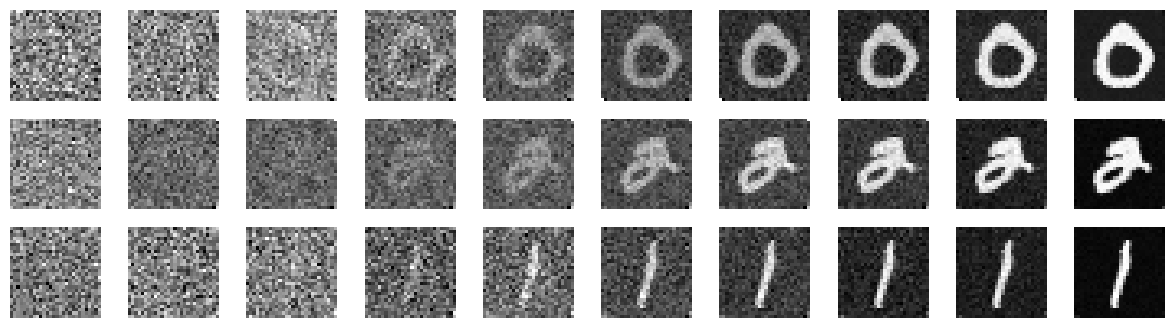

In [ ]:
_ = plot_image_evolution(
    images=synthetic_images_t.cpu(),
    n_images=3,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 470, 480, 490, 500],
    figsize=(15, 4),
)

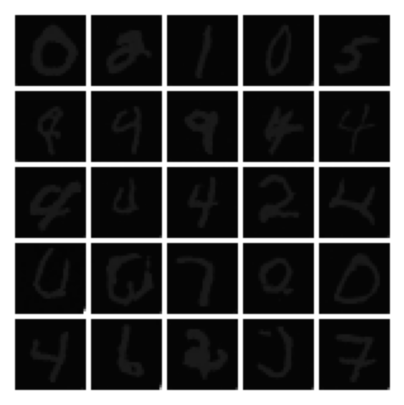

In [ ]:
final_images = synthetic_images_t[..., -1].cpu()

_ = plot_image_grid(
    images=[final_images[i] for i in range(n_images)],
    figsize=(5, 5),
    n_rows=5,
    n_cols=5,
    normalize=True,
)

torch.Size([25, 1, 28, 28, 501])


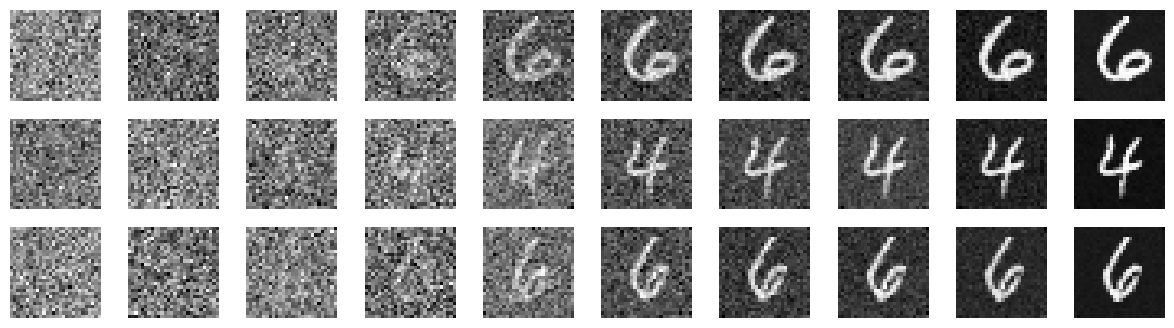

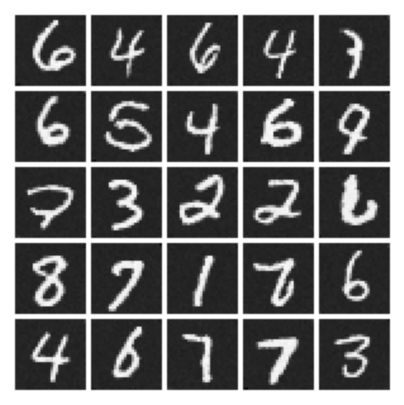

In [ ]:
n_images = 25

times_pc, synthetic_images_t_pc = sample_ou_predictor_corrector(
    score_model=score_model,
    beta_schedule=beta_schedule,
    n_images=n_images,
    image_shape=(1, 28, 28),
    T=1.0,
    t_end=1.0e-3,
    n_steps=500,
    n_corrector_steps=1,
    snr=0.16,
    device=device,
)

print(synthetic_images_t_pc.shape)

_ = plot_image_evolution(
    images=synthetic_images_t_pc.cpu(),
    n_images=3,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 470, 480, 490, 500],
    figsize=(15, 4),
)

final_images_pc = synthetic_images_t_pc[..., -1].cpu()

_ = plot_image_grid(
    images=[final_images_pc[i] for i in range(n_images)],
    figsize=(5, 5),
    n_rows=5,
    n_cols=5,
    normalize=True,
)

torch.Size([25, 1, 28, 28, 501])


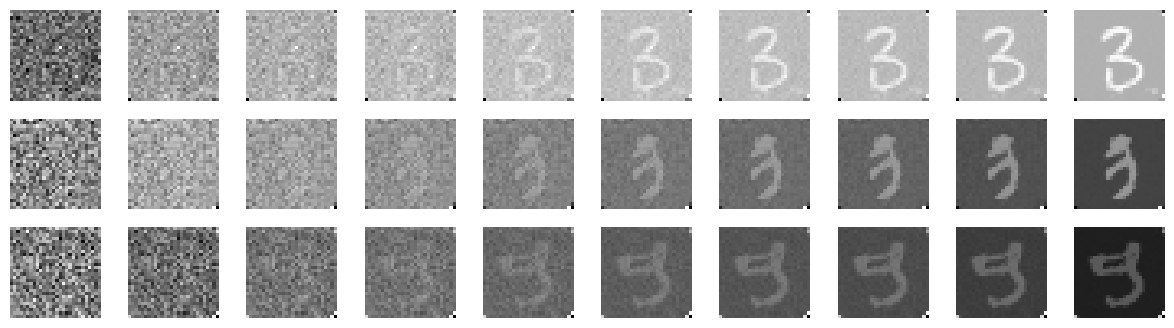

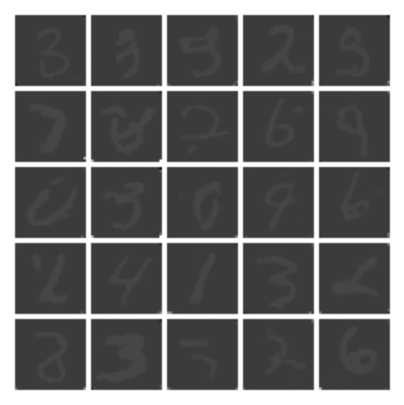

In [ ]:
n_images = 25

times_ode, synthetic_images_t_ode = sample_ou_probability_flow_ode(
    score_model=score_model,
    beta_schedule=beta_schedule,
    n_images=n_images,
    image_shape=(1, 28, 28),
    T=1.0,
    t_end=1.0e-3,
    n_steps=500,
    device=device,
)

print(synthetic_images_t_ode.shape)

_ = plot_image_evolution(
    images=synthetic_images_t_ode.cpu(),
    n_images=3,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 470, 480, 490, 500],
    figsize=(15, 4),
)

final_images_ode = synthetic_images_t_ode[..., -1].cpu()

_ = plot_image_grid(
    images=[final_images_ode[i] for i in range(n_images)],
    figsize=(5, 5),
    n_rows=5,
    n_cols=5,
    normalize=True,
)

In [ ]:
print("Best training loss:", best_loss)

Best training loss: 23.76311866048177
